# 🎯 Módulo 01: Machine Learning Estadístico & Optimización Convexa
## Capítulo 4: Teoría de Generalización, el Dilema Sesgo-Varianza y Validación Rigurosa

> *"Memorizar datos es trivial en informática: basta una tabla hash O(1). La verdadera inteligencia computacional no consiste en almacenar lo que has visto, sino en predecir con rigor sobre lo que jamás se te mostró."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/01_classical_ml/04_generalization_and_evaluation.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías necesarias y fijamos semillas para asegurar reproducibilidad.

In [1]:
# !pip install -q numpy matplotlib scikit-learn
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("✅ Entorno listo para estudiar la teoría de generalización y evaluación")

✅ Entorno listo para estudiar la teoría de generalización y evaluación


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Problema de la Inducción: De David Hume al Aprendizaje Computacional
En el siglo XVIII, el filósofo escocés **David Hume** planteó un enigma que atormentó a la ciencia durante siglos: *¿Con qué justificación lógica asumimos que el futuro se comportará como el pasado?* El hecho de haber visto salir el sol mil días seguidos no garantiza deductivamente que saldrá mañana.

En informática, este problema se traduce directamente en: **¿Por qué debería un modelo predecir correctamente sobre datos de test que nunca vio durante el entrenamiento?**

### Leslie Valiant y la Teoría PAC (1984): El Premio Turing del Aprendizaje
En 1984, el científico de la computación de Harvard **Leslie Valiant** publicó un artículo histórico en *Communications of the ACM*: *"A Theory of the Learnable"*.

Valiant formalizó el aprendizaje no como magia, sino con el mismo rigor computacional de la teoría de la complejidad ($P$ vs $NP$):
* Introdujo el marco **PAC (Probably Approximately Correct)**.
* Demostró que no podemos exigir que un algoritmo sea 100% certero ni infalible, pero sí podemos garantizar matemáticamente que, con una probabilidad de al menos $1 - \delta$, el error del modelo será menor que $\epsilon$ utilizando un número finito y polinomial de ejemplos de entrenamiento $m$.
* Este trabajo pionero le valió el **Premio Turing en 2010**.

### Geman, Bienenstock y Doursat (1992): El Dilema Sesgo / Varianza
En 1992, en plena fiebre de las redes neuronales, Stuart Geman, Elie Bienenstock y René Doursat publicaron en *Neural Computation* un artículo crucial: *"Neural Networks and the Bias/Variance Dilemma"*.

En él demostraron formalmente que cualquier intento de aproximar una función a partir de muestras ruidosas enfrenta un compromiso matemático inevitable entre dos fuentes de error opuestas: el **sesgo** (incapacidad del modelo de capturar la señal real) y la **varianza** (sensibilidad excesiva a las fluctuaciones aleatorias del dataset concreto).

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Descomposición Matemática del Error Cuadrático Medio

Supongamos que los datos se generan según $y = f(x) + \epsilon$, donde $\epsilon$ es ruido blanco con media 0 y varianza $\sigma^2$.
Si entrenamos un modelo $\hat{f}(x)$ sobre distintos datasets aleatorios, el error esperado sobre una muestra no vista se descompone exactamente en 3 términos aditivos independientes:

$$\mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{(\mathbb{E}[\hat{f}(x)] - f(x))^2}_{\text{Sesgo al cuadrado } (\text{Bias}^2)} + \underbrace{\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]}_{\text{Varianza } (\text{Variance})} + \underbrace{\sigma^2}_{\text{Ruido Irreducible}}$$

* **Sesgo (Bias):** Error sistemático. Mide la distancia entre la "predicción promedio" de nuestra familia de modelos y la verdad absoluta. Si usamos una recta para modelar una onda senoidal, el sesgo es alto (*Underfitting*).
* **Varianza (Variance):** Inestabilidad estocástica. Mide cuánto varía la predicción si cambiamos el dataset de entrenamiento por otro del mismo fenómeno. Si un polinomio de grado 20 oscila salvajemente con cada dato nuevo, la varianza es enorme (*Overfitting*).
* **Ruido Irreducible ($\sigma^2$):** La entropía del universo. Ruido de medición o variables no observadas. Ningún algoritmo del mundo puede predecir por debajo de este límite (la frontera de Bayes).

### La Simulación de Monte Carlo: 50 Mundos Paralelos
Para desarrollar intuición visual, vamos a simular 50 datasets independientes generados por el mismo proceso real subyacente y ajustar tres tipos de modelos:
1. **Baja capacidad (Grado 1 - Recta):** Alto sesgo, varianza casi nula (todas las rectas son similares pero erróneas).
2. **Capacidad óptima (Grado 3):** Bajo sesgo, baja varianza.
3. **Alta capacidad (Grado 12 - Polinomio complejo):** Sesgo cero, pero varianza explosiva (las curvas bailan caóticamente en los extremos).

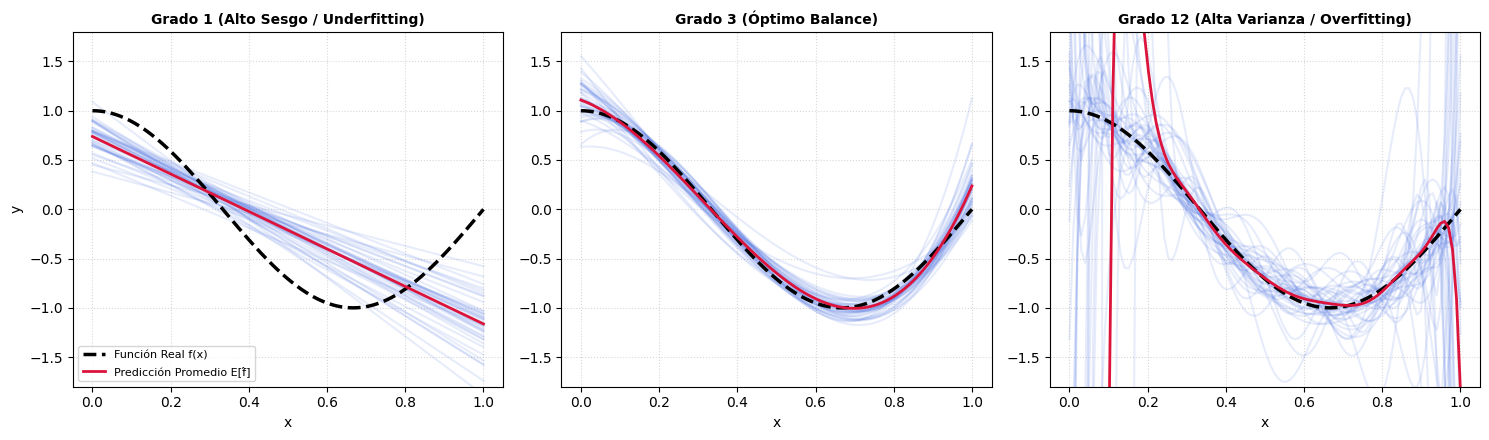

In [2]:
# Experimento de Monte Carlo: 50 mundos paralelos
def funcion_real(x):
    return np.cos(1.5 * np.pi * x)

n_mundos = 40
n_puntos = 25
x_eval = np.linspace(0, 1, 100)

grados = [1, 3, 12]
titulos = ["Grado 1 (Alto Sesgo / Underfitting)", "Grado 3 (Óptimo Balance)", "Grado 12 (Alta Varianza / Overfitting)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx_g, (grado, titulo) in enumerate(zip(grados, titulos)):
    ax = axes[idx_g]
    predicciones = []
    
    for m in range(n_mundos):
        # Generar un dataset independiente con ruido
        x_m = np.sort(np.random.uniform(0, 1, n_puntos))
        y_m = funcion_real(x_m) + np.random.randn(n_puntos) * 0.2
        
        # Ajuste polinomial
        coefs = np.polyfit(x_m, y_m, deg=grado)
        y_pred = np.polyval(coefs, x_eval)
        predicciones.append(y_pred)
        
        # Dibujar cada modelo individual con baja opacidad
        ax.plot(x_eval, y_pred, color='royalblue', alpha=0.12)
        
    predicciones = np.array(predicciones)
    pred_promedio = np.mean(predicciones, axis=0)
    
    # Función real vs Predicción promedio del ensemble de 50 mundos
    ax.plot(x_eval, funcion_real(x_eval), 'k--', linewidth=2.5, label='Función Real f(x)')
    ax.plot(x_eval, pred_promedio, 'crimson', linewidth=2, label='Predicción Promedio E[f̂]')
    
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('x')
    ax.grid(True, linestyle=':', alpha=0.5)
    if idx_g == 0:
        ax.set_ylabel('y')
        ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación Visual:
* En **Grado 1**: Todas las rectas azules están apretadas en un haz estrecho (poca varianza), pero la línea roja promedio está muy lejos de la línea de puntos negra (gran sesgo).
* En **Grado 12**: La línea roja promedio coincide casi exactamente con la verdad (sesgo bajísimo), pero cada modelo individual azul oscila salvajemente (varianza enorme: una predicción individual puede dar $+10$ o $-10$ en los bordes).

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

### Componente 1: Estimación Numérica Exacta de Sesgo y Varianza
Construyamos una función pura que descomponga empíricamente el error cuadrático medio.

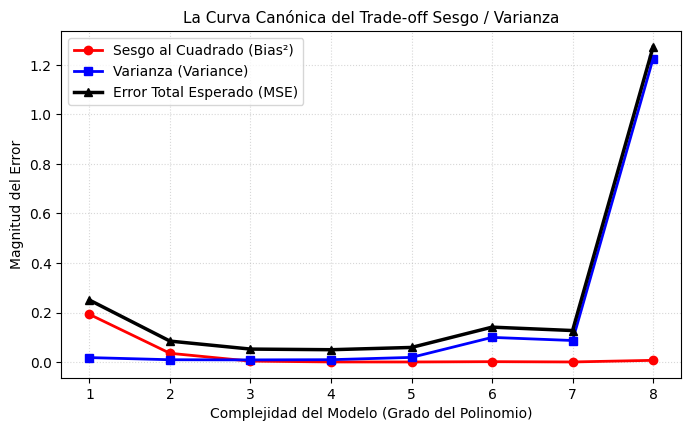

In [3]:
def calcular_bias_variance(
    model_trainer,
    true_fn,
    x_eval: np.ndarray,
    n_datasets: int = 100,
    n_samples: int = 30,
    noise_std: float = 0.2
) -> Tuple[float, float, float, float]:
    """
    Descompone empíricamente el MSE en Bias^2, Varianza y Ruido Irreducible.
    """
    y_true_clean = true_fn(x_eval)
    preds = []
    
    for _ in range(n_datasets):
        x_train = np.random.uniform(0, 1, n_samples)
        y_train = true_fn(x_train) + np.random.randn(n_samples) * noise_std
        model = model_trainer(x_train, y_train)
        preds.append(model(x_eval))
        
    preds = np.array(preds)  # (n_datasets, len(x_eval))
    
    # 1. Esperanza de las predicciones: E[f_hat]
    mean_pred = np.mean(preds, axis=0)
    
    # 2. Sesgo al cuadrado: (E[f_hat] - f(x))^2
    bias_sq = float(np.mean((mean_pred - y_true_clean) ** 2))
    
    # 3. Varianza: E[(f_hat - E[f_hat])^2]
    variance = float(np.mean(np.var(preds, axis=0)))
    
    # 4. Ruido irreducible
    noise = noise_std ** 2
    
    # 5. Error total
    total_mse = bias_sq + variance + noise
    
    return bias_sq, variance, noise, total_mse

# Evaluación comparativa de polinomios de grado 1 a 8
grados_test = list(range(1, 9))
biases, vars_, mses = [], [], []

for g in grados_test:
    b, v, n, tot = calcular_bias_variance(
        model_trainer=lambda x, y, deg=g: (lambda x_t: np.polyval(np.polyfit(x, y, deg), x_t)),
        true_fn=funcion_real,
        x_eval=np.linspace(0, 1, 50),
        n_datasets=80
    )
    biases.append(b)
    vars_.append(v)
    mses.append(tot)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grados_test, biases, 'r-o', label='Sesgo al Cuadrado (Bias²)', linewidth=2)
ax.plot(grados_test, vars_, 'b-s', label='Varianza (Variance)', linewidth=2)
ax.plot(grados_test, mses, 'k-^', label='Error Total Esperado (MSE)', linewidth=2.5)
ax.set_title("La Curva Canónica del Trade-off Sesgo / Varianza", fontsize=11)
ax.set_xlabel("Complejidad del Modelo (Grado del Polinomio)")
ax.set_ylabel("Magnitud del Error")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend()
plt.show()

### Componente 2: Validación Cruzada Estratificada ($K$-Fold) From Scratch

En problemas de clasificación desbalanceados (ej. 95% clase 0 y 5% clase 1), un particionado aleatorio ingenuo puede dejar folds enteros sin ninguna muestra de la clase positiva.

Construyamos un generador de **Stratified $K$-Fold** en Python puro:

In [4]:
def stratified_k_fold(y: np.ndarray, k: int = 5, shuffle: bool = True) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Genera k particiones de índices (train_idx, val_idx) preservando la proporción
    exacta de clases en cada pliegue (Stratified K-Fold from scratch).
    """
    assert k >= 2, "K debe ser al menos 2"
    m = len(y)
    clases = np.unique(y)
    
    # Agrupar índices por cada clase
    indices_por_clase = {}
    for c in clases:
        idx = np.where(y == c)[0].copy()
        if shuffle:
            np.random.shuffle(idx)
        indices_por_clase[c] = idx
        
    # Repartir los índices de cada clase equitativamente entre los k folds
    folds = [[] for _ in range(k)]
    for c in clases:
        idx_c = indices_por_clase[c]
        for i, sample_idx in enumerate(idx_c):
            folds[i % k].append(sample_idx)
            
    # Construir tuplas (train_indices, val_indices)
    splits = []
    all_indices = set(range(m))
    for fold_idx in range(k):
        val_indices = np.array(sorted(folds[fold_idx]))
        train_indices = np.array(sorted(list(all_indices - set(val_indices))))
        splits.append((train_indices, val_indices))
        
    return splits

# Demostración con dataset desbalanceado (90 ceros, 10 unos)
y_desbalanceado = np.array([0] * 90 + [1] * 10)
splits_5 = stratified_k_fold(y_desbalanceado, k=5)

print(f"Total de muestras: {len(y_desbalanceado)} (Proporción clase 1: {np.mean(y_desbalanceado)*100:.0f}%)")
for fold, (train_idx, val_idx) in enumerate(splits_5):
    prop_val = np.mean(y_desbalanceado[val_idx]) * 100
    print(f"Pliegue {fold+1}: Train={len(train_idx)} | Val={len(val_idx)} | % Clase 1 en Val = {prop_val:.1f}%")

Total de muestras: 100 (Proporción clase 1: 10%)
Pliegue 1: Train=80 | Val=20 | % Clase 1 en Val = 10.0%
Pliegue 2: Train=80 | Val=20 | % Clase 1 en Val = 10.0%
Pliegue 3: Train=80 | Val=20 | % Clase 1 en Val = 10.0%
Pliegue 4: Train=80 | Val=20 | % Clase 1 en Val = 10.0%
Pliegue 5: Train=80 | Val=20 | % Clase 1 en Val = 10.0%


### Componente 3: Curva ROC y Métrica AUC From Scratch

En clasificación binaria probabilística, la métrica de **Accuracy** puede ser mortalmente engañosa. Si el 99% de las transacciones son legítimas y el 1% fraude, un modelo bobo que siempre predice "legítimo" tiene un 99% de Accuracy pero es completamente inútil.

La métrica estándar en investigación es el **Área Bajo la Curva ROC (AUC - ROC)**:
* **True Positive Rate (Recall):** $\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
* **False Positive Rate:** $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$

Variamos el umbral de decisión $\tau \in [0, 1]$ de mayor a menor y calculamos el área mediante la regla trapezoidal:

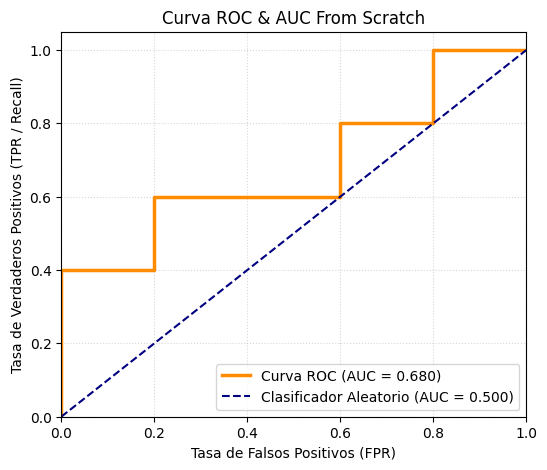

In [5]:
def roc_curve_and_auc(y_true: np.ndarray, y_scores: np.ndarray) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Calcula los puntos (FPR, TPR) y el área bajo la curva (AUC) mediante integración numérica.
    """
    # Ordenar muestras de mayor a menor score predicho
    desc_order = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[desc_order]
    
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    assert n_pos > 0 and n_neg > 0, "Debe haber al menos una muestra de cada clase"
    
    tpr_list = [0.0]
    fpr_list = [0.0]
    tp = 0
    fp = 0
    
    for label in y_true_sorted:
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr_list.append(tp / n_pos)
        fpr_list.append(fp / n_neg)
        
    fpr_arr = np.array(fpr_list)
    tpr_arr = np.array(tpr_list)
    
    # Área bajo la curva mediante la regla trapezoidal: integral de TPR respecto a FPR
    auc = float(np.sum((fpr_arr[1:] - fpr_arr[:-1]) * (tpr_arr[1:] + tpr_arr[:-1]) / 2.0))
    return fpr_arr, tpr_arr, auc

# Prueba de la Curva ROC con un modelo simulado
y_real = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_prob = np.array([0.9, 0.8, 0.7, 0.65, 0.4, 0.35, 0.3, 0.2, 0.15, 0.05])

fpr, tpr, auc_val = roc_curve_and_auc(y_real, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'darkorange', linewidth=2.5, label=f'Curva ROC (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'navy', linestyle='--', label='Clasificador Aleatorio (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC & AUC From Scratch')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

---

## 4. ⚡ Transición a Prácticas Rigurosas en el Ecosistema Moderno

### El Pecado Capital del Investigador: Data Leakage (Fuga de Información)
El error más devastador y común en artículos de investigación es la **fuga de datos del test al entrenamiento**.

```python
# ❌ ERROR COMÚN (Data Leakage):
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)   # ¡PELIGRO! Calcula la media y std de TODO el dataset
# X_train, X_test = train_test_split(X_scaled)  # El test contaminó los parámetros de normalización

# ✅ FORMA CORRECTA:
# X_train, X_test = train_test_split(X)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  # Solo aprende de train
# X_test_scaled = scaler.transform(X_test)        # Aplica los parámetros congelados de train
```

### Las Tres Particiones Inmutables:
1. **Train Set (60-80%):** Utilizado para ajustar los pesos del modelo mediante gradiente.
2. **Validation / Dev Set (10-20%):** Utilizado para seleccionar arquitecturas, tunear hiperparámetros y aplicar *Early Stopping*.
3. **Test Set (10-20%):** La caja fuerte sellada. Se evalúa **una única vez** al finalizar el proyecto para reportar el rendimiento no sesgado.

---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Diagnóstico con Curvas de Aprendizaje (Learning Curves)
¿Cómo sabe un investigador si su red neuronal o modelo necesita **más datos** o **más capacidad**?
Graficando la curva de error de entrenamiento vs error de validación en función del tamaño muestral $m$:
* Si ambas curvas convergen rápidamente pero a un error alto: **Alto Sesgo** (el modelo no da más de sí; añadir datos no servirá de nada, necesitas más parámetros o mejores características).
* Si el error de train es diminuto pero el de validación es alto y no se tocan: **Alta Varianza** (el modelo está sobreajustado; añadir más datos cerrará la brecha).

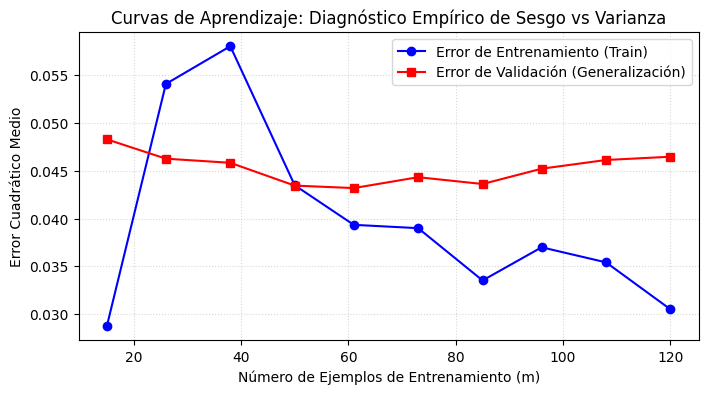

In [6]:
# Curvas de aprendizaje empíricas
tamanios = np.linspace(15, 120, 10, dtype=int)
train_errors = []
val_errors = []

# Generar un conjunto fijo de validación independiente (200 puntos)
x_val_fixed = np.random.uniform(0, 1, 200)
y_val_fixed = funcion_real(x_val_fixed) + np.random.randn(200) * 0.2

for s in tamanios:
    x_sub = np.random.uniform(0, 1, s)
    y_sub = funcion_real(x_sub) + np.random.randn(s) * 0.2
    
    # Ajuste con polinomio de grado 3
    coefs = np.polyfit(x_sub, y_sub, deg=3)
    err_train = np.mean((np.polyval(coefs, x_sub) - y_sub) ** 2)
    err_val = np.mean((np.polyval(coefs, x_val_fixed) - y_val_fixed) ** 2)
    
    train_errors.append(err_train)
    val_errors.append(err_val)

plt.figure(figsize=(8, 4))
plt.plot(tamanios, train_errors, 'b-o', label='Error de Entrenamiento (Train)')
plt.plot(tamanios, val_errors, 'r-s', label='Error de Validación (Generalización)')
plt.title('Curvas de Aprendizaje: Diagnóstico Empírico de Sesgo vs Varianza')
plt.xlabel('Número de Ejemplos de Entrenamiento (m)')
plt.ylabel('Error Cuadrático Medio')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

### Reto 2 (Para resolver): Implementar la Métrica F1-Score Armónica
En problemas con desbalance severo, el $F_1$-score combina la Precisión y el Recall mediante su **media armónica**:
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Implementa a continuación una función que calcule Precision, Recall y F1-score dado el vector de etiquetas verdaderas y predicciones binarias:

In [7]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float, float]:
    """
    Calcula Precision, Recall y F1-score from scratch.
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Valiant, L. G. (1984):** *"A theory of the learnable"*, Communications of the ACM, 27(11), 1134-1142. [ACM Digital Library](https://dl.acm.org/doi/10.1145/1968.1972)
   * *¿Qué leer?* La formulación original de la cota polinomial del número de muestras y la definición formal de la clase PAC.
2. **Geman, S., Bienenstock, E., & Doursat, R. (1992):** *"Neural Networks and the Bias/Variance Dilemma"*, Neural Computation, 4(1), 1-58. [MIT Press Direct](https://doi.org/10.1162/neco.1992.4.1.1)
   * *¿Qué leer?* Sección 3 ("The Bias/Variance Decomposition") para ver la deducción analítica paso a paso del teorema aditivo del error.
3. **Fawcett, T. (2006):** *"An introduction to ROC analysis"*, Pattern Recognition Letters, 27(8), 861-874. [ScienceDirect](https://doi.org/10.1016/j.patrec.2005.10.010)
   * *¿Qué leer?* La explicación geométrica del espacio ROC y por qué es invariante al desbalance de clases a diferencia del Accuracy o Precision/Recall.
4. **Vapnik, V. N. (1998):** *"Statistical Learning Theory"*, John Wiley & Sons.
   * *¿Qué leer?* La definición de la dimensión VC y las cotas de generalización universales.